# 02 — Feature Engineering & Clustering K-means
Identification exploratoire des profils RS (résidence secondaire) et RP (résidence principale) sur RES2-6-9 kVA.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

## 2.1 Chargement des données

In [30]:
df_pivot = pd.read_parquet('../data/pivot.parquet')
df = pd.read_parquet('../data/df_clean.parquet')

print(f"Pivot : {df_pivot.shape}  ({df_pivot.shape[0]} clients × {df_pivot.shape[1]} créneaux)")

Pivot : (500, 17472)  (500 clients × 17472 créneaux)


## 2.2 Feature Engineering

In [31]:
# Colonnes datetime pour les filtres temporels.
cols = pd.to_datetime(df_pivot.columns)
N_SLOTS = 48
n_days = df_pivot.shape[1] // N_SLOTS

mask_nuit = (cols.hour >= 22) | (cols.hour < 6)
mask_jour = ~mask_nuit
mask_ete = cols.month.isin([6, 7, 8])
mask_hiver = cols.month.isin([12, 1, 2])

conso_nuit = df_pivot.loc[:, mask_nuit].sum(axis=1) * 0.5
conso_jour = df_pivot.loc[:, mask_jour].sum(axis=1) * 0.5
conso_ete = df_pivot.loc[:, mask_ete].sum(axis=1) * 0.5
conso_hiver = df_pivot.loc[:, mask_hiver].sum(axis=1) * 0.5
conso_totale = df_pivot.sum(axis=1) * 0.5

# Vrais indicateurs journaliers : une journée active est définie par son énergie totale,
# pas par un nombre de créneaux > 50 W divisé par 48.
values = df_pivot.iloc[:, :n_days * N_SLOTS].to_numpy()
daily_kw = values.reshape(df_pivot.shape[0], n_days, N_SLOTS)
daily_kwh = daily_kw.sum(axis=2) * 0.5

# Dates journalières alignées avec le reshape en blocs de 48 créneaux.
day_dates = pd.to_datetime(df_pivot.columns[:n_days * N_SLOTS][::N_SLOTS])
is_weekend = day_dates.weekday >= 5
is_weekday = ~is_weekend

conso_weekend = daily_kwh[:, is_weekend].sum(axis=1)
conso_semaine = daily_kwh[:, is_weekday].sum(axis=1)
conso_moy_weekend = daily_kwh[:, is_weekend].mean(axis=1)
conso_moy_semaine = daily_kwh[:, is_weekday].mean(axis=1)
ratio_weekend_semaine = conso_moy_weekend / (conso_moy_semaine + 1e-6)
ecart_weekend_semaine = conso_moy_weekend - conso_moy_semaine

nb_jours_actifs = (daily_kwh > 1.0).sum(axis=1)
nb_jours_quasi_nuls = (daily_kwh <= 0.5).sum(axis=1)
taux_jours_actifs = nb_jours_actifs / n_days
conso_moy_jour_actif = conso_totale / np.maximum(nb_jours_actifs, 1)

features = pd.DataFrame({
    'conso_totale': conso_totale,
    'conso_moy_jour': conso_totale / n_days,
    'conso_moy_jour_actif': conso_moy_jour_actif,
    'variance': df_pivot.var(axis=1),
    'pic_max': df_pivot.max(axis=1),
    'ratio_nuit_jour': conso_nuit / (conso_jour + 1e-6),
    'ratio_ete_hiver': (conso_ete + 1.0) / (conso_hiver + 1.0),
    'log_ratio_ete_hiver': np.log1p(conso_ete) - np.log1p(conso_hiver),
    'part_ete': conso_ete / (conso_totale + 1e-6),
    'part_hiver': conso_hiver / (conso_totale + 1e-6),
    'conso_ete': conso_ete,
    'conso_hiver': conso_hiver,
    'conso_semaine': conso_semaine,
    'conso_weekend': conso_weekend,
    'conso_moy_semaine': conso_moy_semaine,
    'conso_moy_weekend': conso_moy_weekend,
    'ratio_weekend_semaine': ratio_weekend_semaine,
    'ecart_weekend_semaine': ecart_weekend_semaine,
    'nb_jours_actifs': nb_jours_actifs,
    'taux_jours_actifs': taux_jours_actifs,
    'nb_jours_quasi_nuls': nb_jours_quasi_nuls,
    'coeff_variation': df_pivot.std(axis=1) / (df_pivot.mean(axis=1) + 1e-6),
}, index=df_pivot.index)

print(f"Features shape : {features.shape}")
print(f"Jours semaine : {is_weekday.sum()}  |  Jours weekend : {is_weekend.sum()}")
features.describe().round(3)


Features shape : (500, 22)
Jours semaine : 260  |  Jours weekend : 104


,conso_totale,conso_moy_jour,conso_moy_jour_actif,variance,pic_max,ratio_nuit_jour,ratio_ete_hiver,log_ratio_ete_hiver,part_ete,part_hiver,...,conso_semaine,conso_weekend,conso_moy_semaine,conso_moy_weekend,ratio_weekend_semaine,ecart_weekend_semaine,nb_jours_actifs,taux_jours_actifs,nb_jours_quasi_nuls,coeff_variation
count,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,...,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000
mean,5797.593,15.927,16.388,0.619,6.058,0.529,2.342,-0.824,0.169,0.375,...,4099.849,1697.745,15.769,16.324,1.037,0.556,353.274,0.971,7.874,1.205
std,1128.356,3.100,2.934,0.161,1.289,0.109,34.669,0.920,0.080,0.114,...,804.164,327.596,3.093,3.150,0.037,0.536,26.254,0.072,22.586,0.196
min,1934.729,5.315,7.402,0.220,3.820,0.276,0.040,-3.225,0.022,0.000,...,1417.597,517.133,5.452,4.972,0.912,-1.574,166.000,0.456,0.000,0.829
25%,5123.891,14.077,14.379,0.502,5.085,0.456,0.258,-1.353,0.115,0.308,...,3611.759,1497.887,13.891,14.403,1.013,0.192,359.000,0.986,0.000,1.075
50%,5787.105,15.899,16.282,0.604,5.716,0.520,0.404,-0.906,0.151,0.381,...,4119.090,1698.502,15.843,16.332,1.034,0.557,364.000,1.000,0.000,1.172
75%,6528.763,17.936,18.407,0.723,6.763,0.594,0.665,-0.408,0.210,0.458,...,4622.518,1916.080,17.779,18.424,1.057,0.874,364.000,1.000,0.000,1.299
max,8866.621,24.359,24.589,1.152,8.998,0.963,774.340,6.652,0.586,0.661,...,6231.711,2634.910,23.968,25.336,1.162,2.374,364.000,1.000,144.000,2.657


## 2.3 Normalisation

In [32]:
feature_cols = features.columns.tolist()

scaler = StandardScaler()
X = scaler.fit_transform(features[feature_cols])


## 2.4 Choix de k — méthode du coude + silhouette

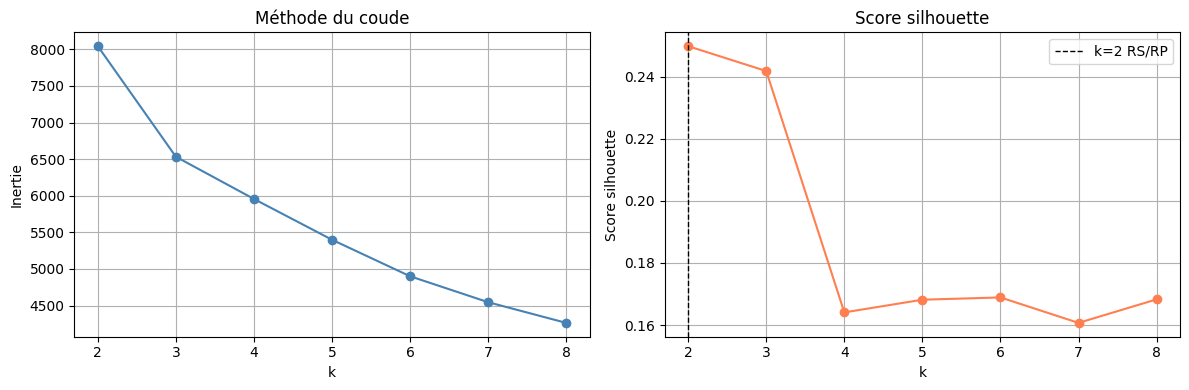

Meilleur k selon silhouette : 2
Pour l'objectif métier RS/RP, on conserve volontairement k=2 dans la suite.


In [33]:
ks = range(2, 9)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labs))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ks, inertias, 'o-', color='steelblue')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertie'); ax1.set_title('Méthode du coude')

ax2.plot(ks, silhouettes, 'o-', color='coral')
ax2.axvline(2, color='black', linestyle='--', linewidth=1, label='k=2 RS/RP')
ax2.set_xlabel('k'); ax2.set_ylabel('Score silhouette'); ax2.set_title('Score silhouette')
ax2.legend()

plt.tight_layout()
plt.show()

best_k = list(ks)[int(np.argmax(silhouettes))]
print(f"Meilleur k selon silhouette : {best_k}")
print("Pour l'objectif métier RS/RP, on conserve volontairement k=2 dans la suite.")


## 2.5 K-means avec k=3

In [34]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(X)
features['cluster'] = labels

print("Répartition :")
print(features['cluster'].value_counts())

print("\nMoyennes par cluster :")
features.select_dtypes(include='number').groupby(features['cluster']).mean().round(3)

Répartition :
cluster
1    261
2    206
0     33
Name: count, dtype: int64

Moyennes par cluster :


,conso_totale,conso_moy_jour,conso_moy_jour_actif,variance,pic_max,ratio_nuit_jour,ratio_ete_hiver,log_ratio_ete_hiver,part_ete,part_hiver,...,conso_weekend,conso_moy_semaine,conso_moy_weekend,ratio_weekend_semaine,ecart_weekend_semaine,nb_jours_actifs,taux_jours_actifs,nb_jours_quasi_nuls,coeff_variation,cluster
cluster,,,,,,,,,,,,,,,,,,,,,
0,3477.679,9.554,12.470,0.416,6.990,0.469,28.299,0.802,0.295,0.210,...,1016.723,9.465,9.776,1.034,0.311,282.758,0.777,66.636,1.649,0.0
1,5308.385,14.583,14.837,0.545,6.005,0.531,0.654,-0.635,0.185,0.339,...,1561.899,14.410,15.018,1.043,0.609,358.398,0.985,3.475,1.219,1.0
2,6789.053,18.651,18.981,0.747,5.975,0.536,0.322,-1.324,0.128,0.446,...,1978.955,18.500,19.028,1.029,0.528,358.078,0.984,4.034,1.115,2.0


## 2.6 Identification RS / RP
Hypothèse métier utilisée pour nommer les clusters :
- **RS (Résidence Secondaire)** : saisonnalité été/hiver plus élevée et présence annuelle plus intermittente.
- **RP (Résidence Principale)** : présence plus régulière et consommation hivernale plus marquée pour RES2.


In [35]:
summary = features.select_dtypes(include='number').groupby(features['cluster']).mean()

rs_score = (
    summary['log_ratio_ete_hiver'].rank(pct=True)
    + summary['part_ete'].rank(pct=True)
    + (-summary['taux_jours_actifs']).rank(pct=True)
    + summary['nb_jours_quasi_nuls'].rank(pct=True)
)
rs_cluster = rs_score.idxmax()
remaining = [c for c in summary.index if c != rs_cluster]

# Parmi les 2 clusters RP, le plus gros consommateur = RP1, l'autre = RP2
rp1_cluster = summary.loc[remaining, 'conso_totale'].idxmax()
rp2_cluster = [c for c in remaining if c != rp1_cluster][0]

features['label'] = features['cluster'].map({
    rs_cluster: 'RS',
    rp1_cluster: 'RP1',
    rp2_cluster: 'RP2'
})

print(f"Cluster {rs_cluster} → RS | Cluster {rp1_cluster} → RP1 | Cluster {rp2_cluster} → RP2")
print("\nRépartition finale :")
print(features['label'].value_counts())

Cluster 0 → RS | Cluster 2 → RP1 | Cluster 1 → RP2

Répartition finale :
label
RP2    261
RP1    206
RS      33
Name: count, dtype: int64


## 2.7 Visualisation PCA 2D

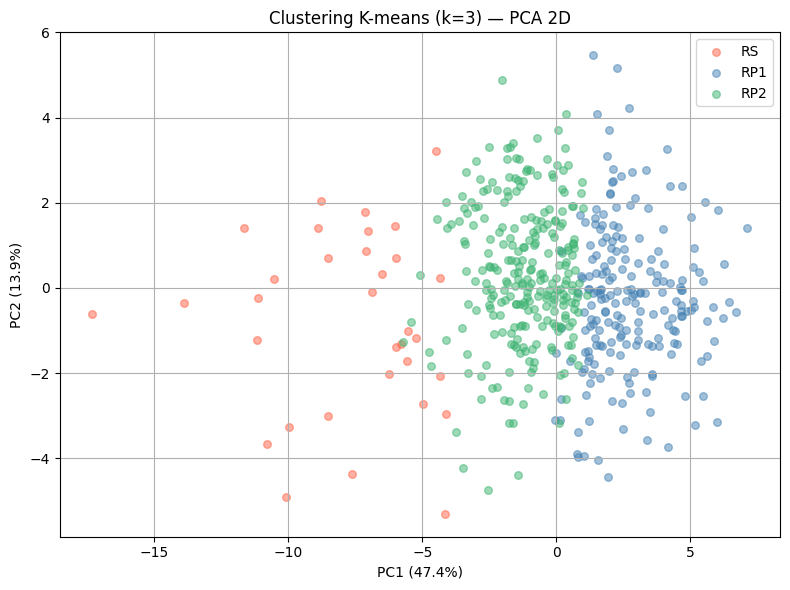

In [36]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

colors = {'RS': 'tomato', 'RP1': 'steelblue', 'RP2': 'mediumseagreen'}
fig, ax = plt.subplots(figsize=(8, 6))

for label, color in colors.items():
    mask = features['label'] == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.5, s=30, label=label)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Clustering K-means (k=3) — PCA 2D')
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
import subprocess
subprocess.run(['pip', 'install', 'nbformat', '--upgrade'], check=True)

CompletedProcess(args=['pip', 'install', 'nbformat', '--upgrade'], returncode=0)

In [38]:
import plotly.graph_objects as go
import plotly.io as pio

# Use notebook_connected renderer for VS Code compatibility
pio.renderers.default = "notebook_connected"

pca3 = PCA(n_components=3)
X_3d = pca3.fit_transform(X)

colors = {'RS': 'tomato', 'RP1': 'steelblue', 'RP2': 'mediumseagreen'}

# Map clusters to labels (using rs_cluster, etc. if available, otherwise fallback)
cluster_map = {0: 'RS', 2: 'RP1', 1: 'RP2'}
if 'rs_cluster' in locals():
    cluster_map = {rs_cluster: 'RS', rp1_cluster: 'RP1', rp2_cluster: 'RP2'}
cluster_labels = features['cluster'].map(cluster_map)

fig = go.Figure()

for label, color in colors.items():
    mask = cluster_labels == label
    fig.add_trace(go.Scatter3d(
        x=X_3d[mask, 0],
        y=X_3d[mask, 1],
        z=X_3d[mask, 2],
        mode='markers',
        name=label,
        marker=dict(color=color, size=4, opacity=0.6)
    ))

fig.update_layout(
    title='Clustering K-means (k=3) — PCA 3D interactif',
    scene=dict(
        xaxis_title=f'PC1 ({pca3.explained_variance_ratio_[0]:.1%})',
        yaxis_title=f'PC2 ({pca3.explained_variance_ratio_[1]:.1%})',
        zaxis_title=f'PC3 ({pca3.explained_variance_ratio_[2]:.1%})',
    ),
    width=900, height=700
)

fig.show()

print(f"Variance expliquée cumulée (3 composantes) : {pca3.explained_variance_ratio_.sum():.1%}")

Variance expliquée cumulée (3 composantes) : 73.8%


## 2.8 Profils moyens RS vs RP (journée type)

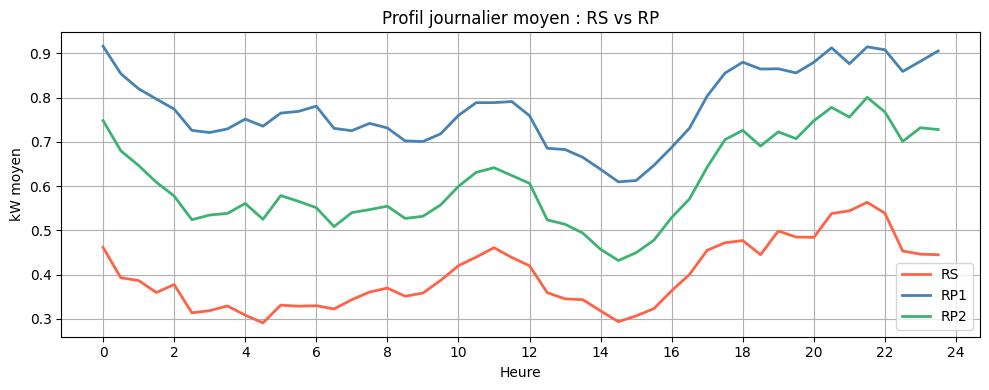

In [39]:
df['label'] = df['ID'].map(features['label'])
df['hour'] = df['horodate'].dt.hour + df['horodate'].dt.minute / 60

hourly = df.groupby(['label', 'hour'])['kw'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
for label, color in colors.items():
    sub = hourly[hourly['label'] == label]
    ax.plot(sub['hour'], sub['kw'], color=color, linewidth=2, label=label)

ax.set_xlabel('Heure'); ax.set_ylabel('kW moyen')
ax.set_title('Profil journalier moyen : RS vs RP')
ax.legend(); ax.set_xticks(range(0, 25, 2))
plt.tight_layout()
plt.show()

## 2.9 Sauvegarde

In [40]:
# Fusion RP1 et RP2 en un seul label RP
features['label'] = features['label'].replace({'RP1': 'RP', 'RP2': 'RP'})

print("Répartition finale après fusion RP1/RP2 :")
print(features['label'].value_counts())

Répartition finale après fusion RP1/RP2 :
label
RP    467
RS     33
Name: count, dtype: int64


In [41]:
import joblib
import json

features[['cluster', 'label']].to_csv('../data/labels.csv')
features.to_parquet('../data/features.parquet')
joblib.dump(scaler, '../models/scaler_features.pkl')
joblib.dump(km, '../models/kmeans.pkl')
with open('../models/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)

print("Sauvegardé : labels.csv, features.parquet, scaler_features.pkl, kmeans.pkl, feature_cols.json")


Sauvegardé : labels.csv, features.parquet, scaler_features.pkl, kmeans.pkl, feature_cols.json
